In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sy
from scipy.sparse import csr_matrix, lil_matrix
from scipy import sparse
from numpy import array
from scipy.sparse.linalg import spsolve
import matplotlib as mpl
mpl.rcParams['figure.dpi']= 300
from tabulate import tabulate


In [ ]:
# set cross section
LX = 100 #width
NEL = 80 #number of elements

dx = np.ones(NEL) * LX / NEL
NEL2COORD = np.cumsum(dx) - dx / 2

D = np.ones(NEL)*1.36  # diffusion coefficient
SigT = np.ones(NEL)*0.0181  # macroscopic cross section
Q = np.ones(NEL)*1

Lhs = lil_matrix((NEL, NEL))
Rhs = np.zeros(NEL)
for iel in range(NEL):
    D0  = D[iel]
    dx0 = dx[iel]
    if iel==0:
        # Dxm = -D0/(2.1312*D0 + dx0/2) #vacuum boundary
        # Dxm = 0 #reflective boundary
        Dxm = -D0/(dx0/2) #zero boundary
    else:
        Dm  = D[iel-1]
        dxm = dx[iel-1]
        Dxm = -2*Dm*D0/(Dm*dx0 + D0*dxm)
    if iel==NEL-1:
        # Dxp = -D0/(2.1312*D0 + dx0/2) #vacuum boundary
        # Dxp = 0 #reflective boundary
        Dxp = -D0/(dx0/2) #zero boundary
        
    else:
        Dp  = D[iel+1]
        dxp = dx[iel+1]
        Dxp = -2*D0*Dp/(D0*dxp + Dp*dx0)

    A0 = SigT[iel] - ((Dxm+Dxp)/dx0)
    Lhs[iel, iel] = A0
    if iel != 0:
        Lhs[iel, iel-1] = Dxm/dx0
    if iel != NEL - 1:
        Lhs[iel, iel+1] = Dxp/dx0
        
    Rhs[iel] = Q[iel]

Phi = spsolve(Lhs.tocsr(), Rhs)


[1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25]


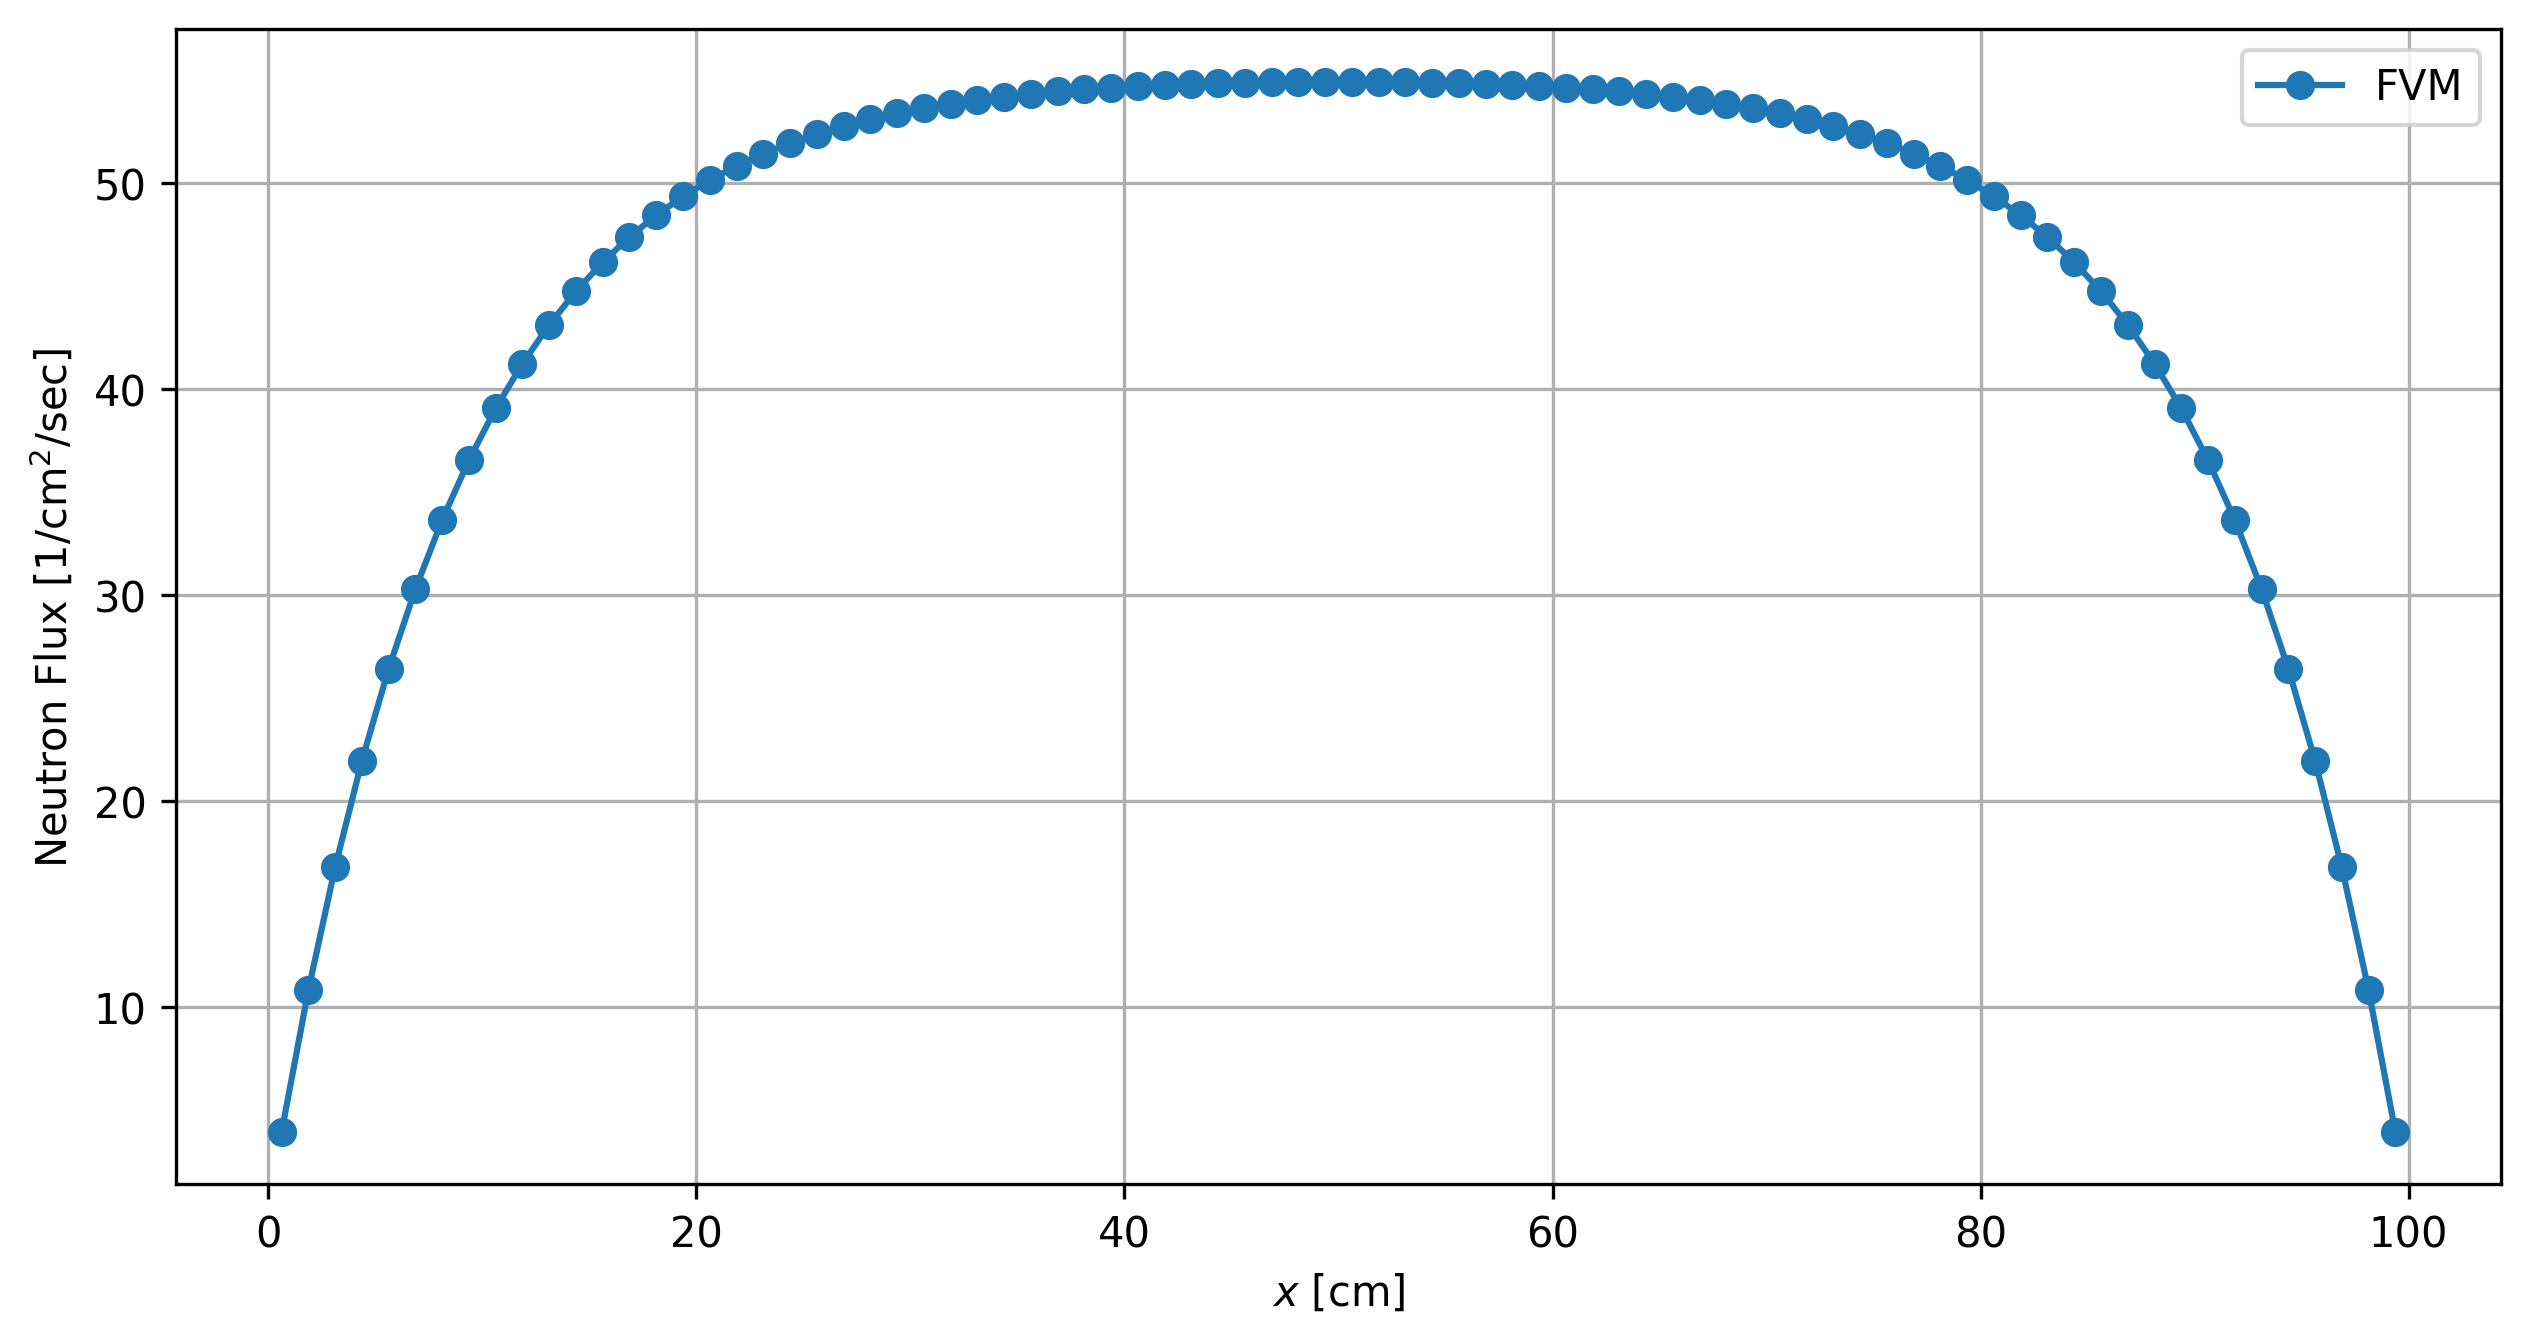

In [19]:
# プロット
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel(r'$x$ [cm]')
ax.set_ylabel(r'Neutron Flux [1/cm$^2$/sec]')
ax.plot(NEL2COORD, Phi, label='FVM', marker='o')
ax.legend()
plt.grid(True)

plt.show()